This notebook answers the remaining research question from `07` and `08` code files: Which service
aspects/features actually drive `Recommended` predictions, and does this differ across
Sets?

SHAP values are computed on the tuned LightGBM pipeline for each of the 6 Sets (`lgbm_tuned_{Set}.joblib` from `08_hyperparameter_tuning.ipynb`), evaluated on the same held-out chronological test set used throughout this project.
`shap.TreeExplainer` is used since LightGBM is a tree-based model, giving exact (non-approximate) Shapley values.

- **Note on cross-Set comparison:** each Set uses a different feature engineering
methodology (numeric ratings, VADER, rule-based aspects, BERT variants), so raw feature
names differ across Sets (e.g. Set C's "aspect_seat" vs Set E2's "absa_seat_e2"). This
notebook first surfaces each Set's actual feature names, then maps equivalent service
aspects (Seat, Staff, Food, Ground Service, Entertainment, Value For Money) across Sets
using a verified mapping (`ASPECT_MAP`), so their relative importance can be compared on
a common scale (normalized rank) despite differing units and feature counts. Set B has
no aspect-level breakdown (VADER scores are document-level, not per-aspect) and is
included in per-Set analyses but excluded from the cross-Set aspect comparison.

- **Note:** Set A does not have an Entertainment counterpart. **Inflight Entertainment** and **Wifi & Connectivity** were dropped in `06_feature_sets.ipynb` due to high missingness, before the rating columns were finalized as `RATING_COLS` in
`modelling_utils.py`. This is why `ASPECT_MAP`'s "Entertainment" row has no "A" entry.

## **0. Setup**

In [19]:
pip install shap --break-system-packages -q

Note: you may need to restart the kernel to use updated packages.


In [20]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from scipy.sparse import issparse

from modelling_utils import TARGET, SET_SCHEMA, load_sets_and_split

DATA_DIR = "../1_data/02_final_sets/"
METRICS_DIR = "../3_results/01_metrics/"
FIGURES_DIR = "../3_results/02_figures/"
MODEL_DIR = "fitted_pipelines/"
os.makedirs(FIGURES_DIR, exist_ok=True)

SET_FILES = {
    "A": "01_set_a.csv", "B": "02_set_b.csv", "C": "03_set_c.csv",
    "D": "04_set_d.csv", "E1": "05_set_e1.csv", "E2": "06_set_e2.csv",
}

## **1. Load Data and Tuned Models**

In [21]:
sets, splits = load_sets_and_split(DATA_DIR, SET_FILES)
print(f"Test size (Set A, shared row_id across Sets): {len(splits['A']['test'])}")

Test size (Set A, shared row_id across Sets): 4596


In [22]:
tuned_lgbm = {}
for set_name in SET_FILES:
    path = f"{MODEL_DIR}lgbm_tuned_{set_name}.joblib"
    tuned_lgbm[set_name] = joblib.load(path)
    print(f"Loaded {path}")

Loaded fitted_pipelines/lgbm_tuned_A.joblib
Loaded fitted_pipelines/lgbm_tuned_B.joblib
Loaded fitted_pipelines/lgbm_tuned_C.joblib
Loaded fitted_pipelines/lgbm_tuned_D.joblib
Loaded fitted_pipelines/lgbm_tuned_E1.joblib
Loaded fitted_pipelines/lgbm_tuned_E2.joblib


## **2. Inspect Each Set's Feature Names**

In [23]:
def get_feature_names(pipe):
    """Feature names as they enter the final 'model' step (post-preprocessing)."""
    return pipe.named_steps["preprocess"].get_feature_names_out()

feature_names_by_set = {}
for set_name, pipe in tuned_lgbm.items():
    names = get_feature_names(pipe)
    feature_names_by_set[set_name] = names
    print(f"\n=== Set {set_name}: {len(names)} features ===")
    print(list(names))


=== Set A: 22 features ===
['cat__Type Of Traveller_Business', 'cat__Type Of Traveller_Couple Leisure', 'cat__Type Of Traveller_Family Leisure', 'cat__Type Of Traveller_Solo Leisure', 'cat__Type Of Traveller_Unknown', 'cat__Seat Type_Business Class', 'cat__Seat Type_Economy Class', 'cat__Seat Type_First Class', 'cat__Seat Type_Premium Economy', 'cat__Seat Type_Unknown', 'num_continuous__Seat Comfort', 'num_continuous__Cabin Staff Service', 'num_continuous__Food & Beverages', 'num_continuous__Ground Service', 'num_continuous__Value For Money', 'num_continuous__review_length', 'num_binary__Seat Comfort_missing', 'num_binary__Cabin Staff Service_missing', 'num_binary__Food & Beverages_missing', 'num_binary__Ground Service_missing', 'num_binary__Value For Money_missing', 'num_binary__Verified']

=== Set B: 16 features ===
['cat__Type Of Traveller_Business', 'cat__Type Of Traveller_Couple Leisure', 'cat__Type Of Traveller_Family Leisure', 'cat__Type Of Traveller_Solo Leisure', 'cat__Type O

## **3. Cross-Set Aspect Mapping**

Set B is excluded from the aspect-level mapping and cross-Set aspect comparison, since
VADER (Set B) produces a single sentiment score for the entire review document rather
than separate scores per service aspect. Set B is still included in every other,
per-Set analysis (e.g. feature importance, SHAP dependence plots).

In [24]:
ASPECT_MAP = {
    "Seat":            {"A": "num_continuous__Seat Comfort",
                         "C": "num_nan__aspect_seat",
                         "D": "num_nan__aspect_seat",
                         "E1": "num_continuous__absa_seat",
                         "E2": "num_nan__absa_seat_e2"},
    "Staff":           {"A": "num_continuous__Cabin Staff Service",
                         "C": "num_nan__aspect_staff",
                         "D": "num_nan__aspect_staff",
                         "E1": "num_continuous__absa_staff",
                         "E2": "num_nan__absa_staff_e2"},
    "Food":            {"A": "num_continuous__Food & Beverages",
                         "C": "num_nan__aspect_food",
                         "D": "num_nan__aspect_food",
                         "E1": "num_continuous__absa_food",
                         "E2": "num_nan__absa_food_e2"},
    "Ground Service":  {"A": "num_continuous__Ground Service",
                         "C": "num_nan__aspect_ground_service",
                         "D": "num_nan__aspect_ground_service",
                         "E1": "num_continuous__absa_ground_service",
                         "E2": "num_nan__absa_ground_service_e2"},
    "Entertainment":   {"C": "num_nan__aspect_entertainment",
                         "D": "num_nan__aspect_entertainment",
                         "E1": "num_continuous__absa_entertainment",
                         "E2": "num_nan__absa_entertainment_e2"},
    "Value For Money": {"A": "num_continuous__Value For Money"},
}

# Sanity check: every mapped feature name actually exists in that Set's feature list
for aspect, set_map in ASPECT_MAP.items():
    for set_name, feat_name in set_map.items():
        assert feat_name in feature_names_by_set[set_name], (
            f"'{feat_name}' not found in Set {set_name}'s features -- check feature name output"
        )
print("All ASPECT_MAP entries verified against actual feature names.")

All ASPECT_MAP entries verified against actual feature names.


## **4. SHAP Calculation**

In [25]:
def compute_shap(pipe, X_test):
    """
    Transform X_test through every pipeline step except the final classifier,
    then compute exact SHAP values on the resulting features via TreeExplainer.
    """
    X_transformed = pipe[:-1].transform(X_test)
    if issparse(X_transformed):
        X_transformed = X_transformed.toarray()

    model = pipe.named_steps["model"]
    explainer = shap.TreeExplainer(model)
    explanation = explainer(X_transformed)

    values = explanation.values
    # Newer shap versions return (n_samples, n_features, n_classes) for binary
    # classifiers; select the positive class (Recommended=1).
    if values.ndim == 3:
        values = values[:, :, 1]

    return values, X_transformed

shap_results = {}  # set_name -> (shap_values, X_transformed)

for set_name, pipe in tuned_lgbm.items():
    X_test = splits[set_name]["test"].drop(columns=[TARGET])
    values, X_transformed = compute_shap(pipe, X_test)
    shap_results[set_name] = (values, X_transformed)
    print(f"Set {set_name}: SHAP values shape = {values.shape}")

Set A: SHAP values shape = (4596, 22)
Set B: SHAP values shape = (4596, 16)
Set C: SHAP values shape = (4596, 22)
Set D: SHAP values shape = (4596, 26)
Set E1: SHAP values shape = (4596, 17)
Set E2: SHAP values shape = (4596, 22)


## **5. Global Feature Importance per Set**

In [26]:
importance_tables = {}

for set_name in SET_FILES:
    values, _ = shap_results[set_name]
    names = feature_names_by_set[set_name]
    mean_abs_shap = np.abs(values).mean(axis=0)

    imp_df = pd.DataFrame({
        "Feature": names,
        "Mean_Abs_SHAP": mean_abs_shap,
    }).sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)
    imp_df["Rank"] = imp_df.index + 1
    imp_df["Set"] = set_name

    importance_tables[set_name] = imp_df

    print(f"\n=== Set {set_name}: Top 15 features by mean |SHAP| ===")
    print(imp_df[["Rank", "Feature", "Mean_Abs_SHAP"]].head(15).to_string(index=False))


=== Set A: Top 15 features by mean |SHAP| ===
 Rank                                 Feature  Mean_Abs_SHAP
    1         num_continuous__Value For Money       1.744746
    2          num_continuous__Ground Service       0.769567
    3     num_continuous__Cabin Staff Service       0.642446
    4            num_continuous__Seat Comfort       0.433653
    5        num_continuous__Food & Beverages       0.194497
    6           num_continuous__review_length       0.084843
    7                    num_binary__Verified       0.069464
    8                  cat__Seat Type_Unknown       0.047358
    9          cat__Type Of Traveller_Unknown       0.042643
   10      num_binary__Ground Service_missing       0.036515
   11     num_binary__Value For Money_missing       0.019121
   12 num_binary__Cabin Staff Service_missing       0.012320
   13           cat__Seat Type_Business Class       0.012222
   14            cat__Seat Type_Economy Class       0.011735
   15   cat__Type Of Traveller_Family 

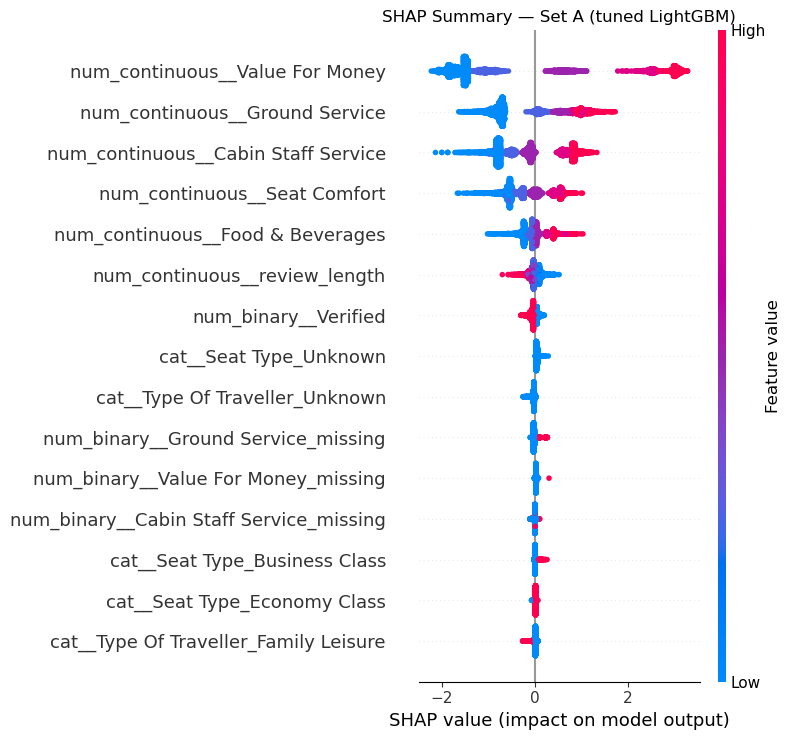

Saved: ../3_results/02_figures/shap_summary_set_A.png


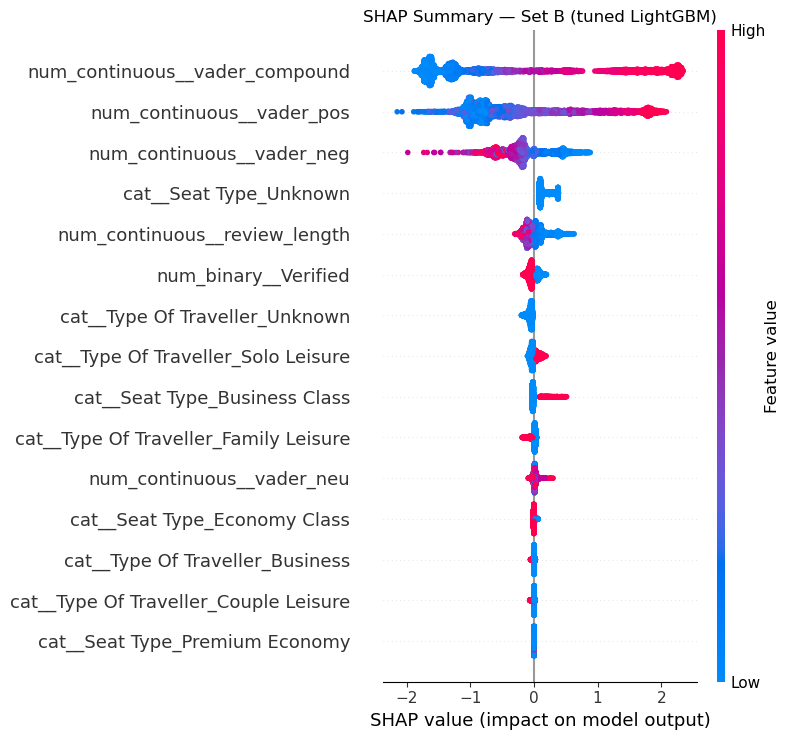

Saved: ../3_results/02_figures/shap_summary_set_B.png


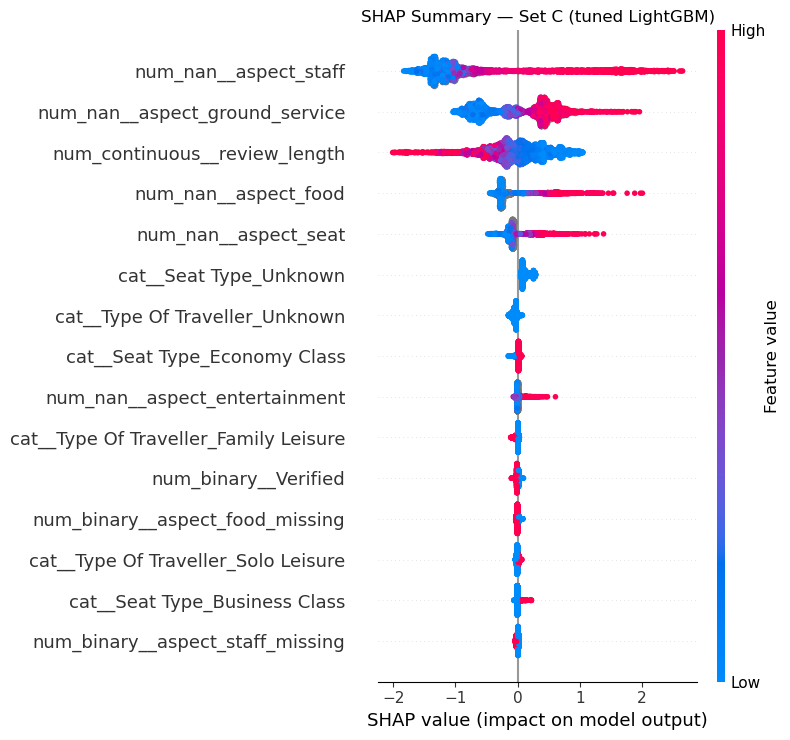

Saved: ../3_results/02_figures/shap_summary_set_C.png


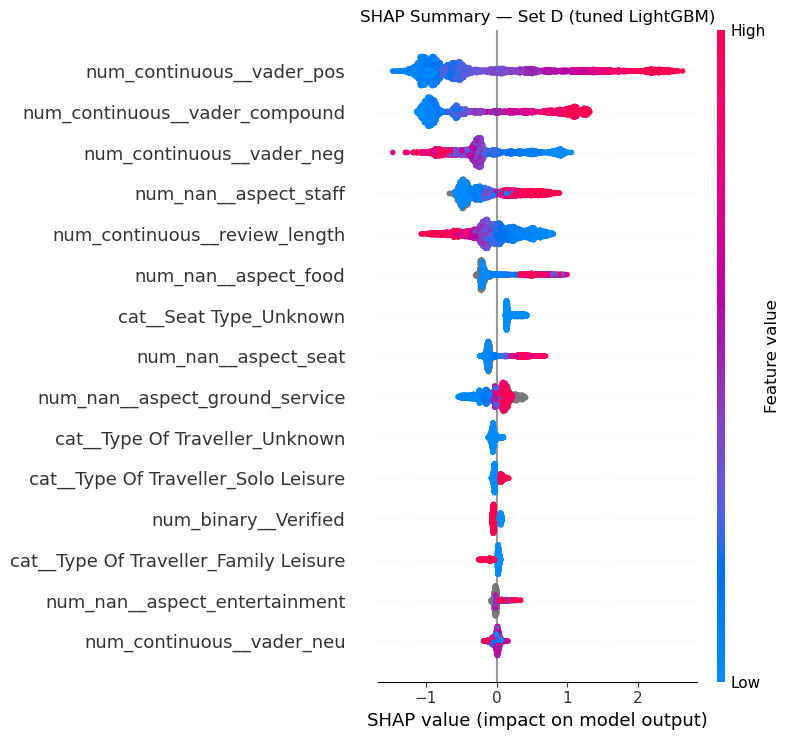

Saved: ../3_results/02_figures/shap_summary_set_D.png


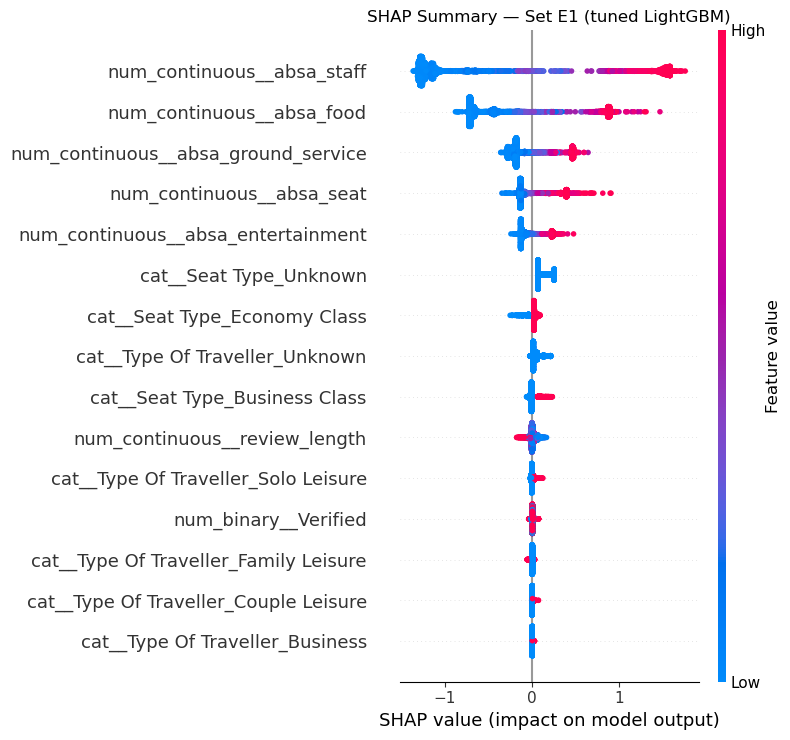

Saved: ../3_results/02_figures/shap_summary_set_E1.png


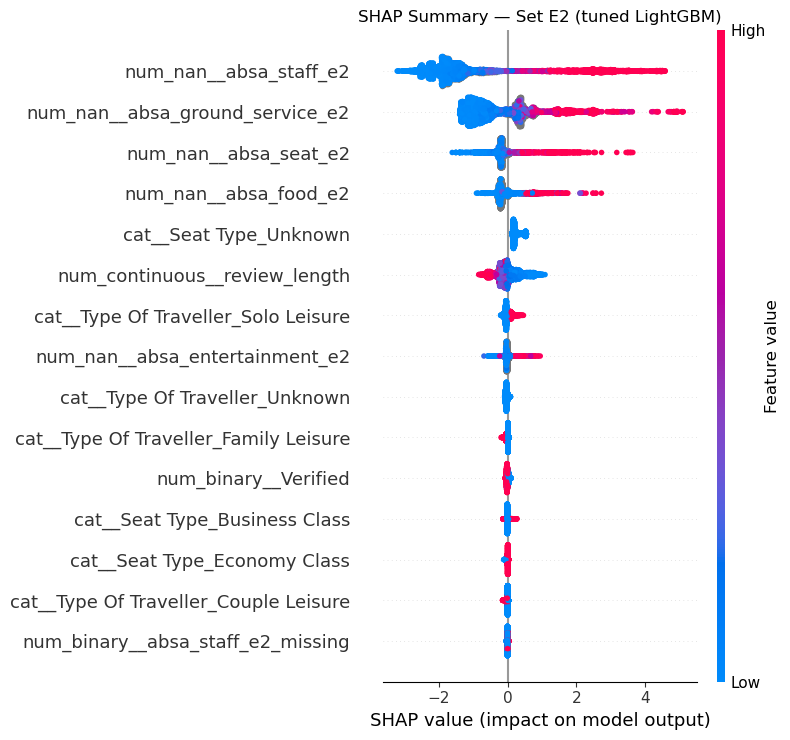

Saved: ../3_results/02_figures/shap_summary_set_E2.png


In [27]:
for set_name in SET_FILES:
    values, X_transformed = shap_results[set_name]
    names = feature_names_by_set[set_name]

    plt.figure()
    shap.summary_plot(values, X_transformed, feature_names=names, show=False, max_display=15)
    plt.title(f"SHAP Summary — Set {set_name} (tuned LightGBM)")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}shap_summary_set_{set_name}.png", dpi=150, bbox_inches="tight")
    plt.show()   # ← 저장 후 화면에도 표시
    plt.close()
    print(f"Saved: {FIGURES_DIR}shap_summary_set_{set_name}.png")

## **6. Cross-Set Aspect Importance Comparison**

In [28]:
cross_set_rows = []
for aspect, set_map in ASPECT_MAP.items():
    for set_name, feat_name in set_map.items():
        imp_df = importance_tables[set_name]
        row = imp_df[imp_df["Feature"] == feat_name].iloc[0]
        cross_set_rows.append({
            "Aspect": aspect,
            "Set": set_name,
            "Raw_Feature": feat_name,
            "Mean_Abs_SHAP": row["Mean_Abs_SHAP"],
            "Rank_within_Set": row["Rank"],
            "Total_Features_in_Set": len(feature_names_by_set[set_name]),
        })

cross_set_df = pd.DataFrame(cross_set_rows)
cross_set_df["Normalized_Rank"] = (
    (cross_set_df["Rank_within_Set"] - 1) / (cross_set_df["Total_Features_in_Set"] - 1)
)

pivot_rank = cross_set_df.pivot(index="Aspect", columns="Set", values="Normalized_Rank")
pivot_shap = cross_set_df.pivot(index="Aspect", columns="Set", values="Mean_Abs_SHAP")

print("=== Normalized importance rank per aspect, per Set (0 = most important) ===")
print(pivot_rank.round(3))

print("\n=== Raw Mean |SHAP| per aspect, per Set (scales differ across Sets -- not directly comparable) ===")
print(pivot_shap.round(4))

aspect_avg_rank = pivot_rank.mean(axis=1).sort_values()
print("\n=== Aspects ranked by average normalized importance across Sets ===")
print(aspect_avg_rank.round(3))

=== Normalized importance rank per aspect, per Set (0 = most important) ===
Set                  A      C     D     E1     E2
Aspect                                           
Entertainment      NaN  0.381  0.52  0.250  0.333
Food             0.190  0.143  0.20  0.062  0.143
Ground Service   0.048  0.048  0.32  0.125  0.048
Seat             0.143  0.190  0.28  0.188  0.095
Staff            0.095  0.000  0.12  0.000  0.000
Value For Money  0.000    NaN   NaN    NaN    NaN

=== Raw Mean |SHAP| per aspect, per Set (scales differ across Sets -- not directly comparable) ===
Set                   A       C       D      E1      E2
Aspect                                                 
Entertainment       NaN  0.0205  0.0429  0.1316  0.0743
Food             0.1945  0.3335  0.2701  0.6500  0.2935
Ground Service   0.7696  0.5184  0.1529  0.2411  0.8878
Seat             0.4337  0.1725  0.1727  0.1791  0.3361
Staff            0.6424  1.1485  0.3657  1.1961  1.8437
Value For Money  1.7447     NaN 

## **7. Cross-Set Aspect Importance Charts**

**Note** Set A shows no bar for "Entertainment," and no Set other than
A shows a bar for "Value For Money." This is not missing data; it reflects the
`ASPECT_MAP` structure itself: "Value For Money" exists only in Set A, and "Entertainment" not exists in Set A
(dropped earlier due to high missingness). Since each bar in this
chart requires a value for that (Aspect, Set) pair, and these two aspects have `NaN`
for the Sets that lack them, no bar is drawn there -- the bar isn't small or zero, it
simply has no data to plot.

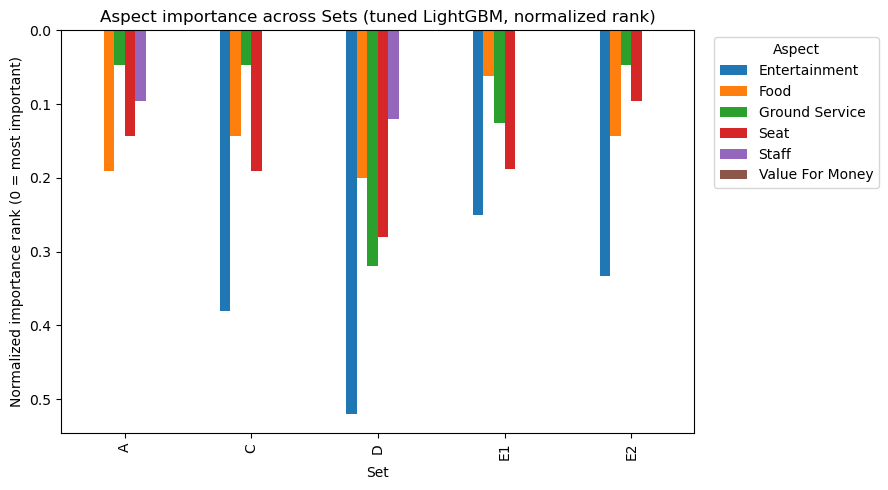

Saved: ../3_results/02_figures/shap_cross_set_aspect_importance.png


In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot_rank.T.plot(kind="bar", ax=ax)
ax.set_ylabel("Normalized importance rank (0 = most important)")
ax.set_xlabel("Set")
ax.set_title("Aspect importance across Sets (tuned LightGBM, normalized rank)")
ax.invert_yaxis()
ax.legend(title="Aspect", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}shap_cross_set_aspect_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR}shap_cross_set_aspect_importance.png")

## **8. Penalty vs. Reward Analyis (to compensate the limitation of SHAP analysis)**

`Mean_Abs_SHAP` only captures the **magnitude** of a feature's influence on the prediction. **It cannot distinguish why a feature is important.** A feature could be important because it behaves **hygienically** (a bad experience severely drives non-recommendation, but a good experience adds little beyond what's already expected), because it behaves as a **motivator** (a good experience meaningfully lifts recommendation, but a bad experience isn't strongly punished), or because it behaves **linearly/symmetrically** (equally influential in both directions). All three patterns can produce an identical `Mean_Abs_SHAP` value, since the metric is computed on absolute values and cannot separate the direction or asymmetry of the underlying relationship.

Therefore, for each Set/aspect pair, SHAP values are split by the feature's own bottom-25% ("bad service") vs. top-25% ("good service") quantiles. The mean SHAP value within each group approximates the average penalty incurred for bad service and the
average reward earned for good service, respectively; their ratio (Penalty or Reward) indicates which pattern dominates:

| Ratio | Interpretation |
|---|---|
| > 1.5 | Hygiene-like: penalty for bad service outweighs reward for good service |
| < 0.67 | Motivator-like: reward for good service outweighs penalty for bad service |
| 0.67 - 1.5 | Roughly symmetric / linear |

In [30]:
def asymmetry_check(set_name, feature_name, low_pct=25, high_pct=75):
    """
    Compares the mean SHAP value in the bottom vs top quantile of a feature's
    observed values, to check for hygiene-factor asymmetry (bad service -> large
    negative penalty, good service -> little positive reward) vs. motivator asymmetry
    (the reverse) vs. roughly linear/symmetric behavior.
    """
    values, X_transformed = shap_results[set_name]
    names = feature_names_by_set[set_name]
    idx = list(names).index(feature_name)

    feat_vals = X_transformed[:, idx]
    shap_vals = values[:, idx]

    # Drop rows where this feature was missing-indicator-filled at 0 with no signal,
    # only if there's an associated *_missing column -- otherwise just use as-is.
    valid = ~np.isnan(feat_vals)
    feat_vals, shap_vals = feat_vals[valid], shap_vals[valid]

    low_thresh = np.percentile(feat_vals, low_pct)
    high_thresh = np.percentile(feat_vals, high_pct)

    low_mask = feat_vals <= low_thresh
    high_mask = feat_vals >= high_thresh

    low_shap_mean = shap_vals[low_mask].mean() if low_mask.sum() > 0 else np.nan
    high_shap_mean = shap_vals[high_mask].mean() if high_mask.sum() > 0 else np.nan

    penalty = abs(low_shap_mean)
    reward = abs(high_shap_mean)
    ratio = penalty / reward if reward > 1e-6 else np.inf

    if ratio > 1.5:
        pattern = "Hygiene-like (penalty >> reward)"
    elif ratio < 0.67:
        pattern = "Motivator-like (reward >> penalty)"
    else:
        pattern = "Roughly symmetric / linear"

    return {
        "Low_group_mean_SHAP": low_shap_mean,
        "High_group_mean_SHAP": high_shap_mean,
        "Penalty_vs_Reward_ratio": ratio,
        "Pattern": pattern,
        "N_low": low_mask.sum(),
        "N_high": high_mask.sum(),
    }


# Run across all six Sets, using ASPECT_MAP to resolve each Set's actual feature name
asymmetry_results = []

for aspect, set_map in ASPECT_MAP.items():
    for set_name, feat_name in set_map.items():
        result = asymmetry_check(set_name, feat_name)
        result.update({"Aspect": aspect, "Set": set_name, "Feature": feat_name})
        asymmetry_results.append(result)

asymmetry_df = pd.DataFrame(asymmetry_results)[
    ["Aspect", "Set", "Feature", "Low_group_mean_SHAP", "High_group_mean_SHAP",
     "Penalty_vs_Reward_ratio", "Pattern", "N_low", "N_high"]
]

pd.set_option("display.width", 160)
print(asymmetry_df.round(4).to_string(index=False))

         Aspect Set                             Feature  Low_group_mean_SHAP  High_group_mean_SHAP  Penalty_vs_Reward_ratio                            Pattern  N_low  N_high
           Seat   A        num_continuous__Seat Comfort              -0.6140                0.2837                   2.1643   Hygiene-like (penalty >> reward)   1809    1944
           Seat   C                num_nan__aspect_seat              -0.1982                0.4523                   0.4383 Motivator-like (reward >> penalty)    412     412
           Seat   D                num_nan__aspect_seat              -0.1136                0.3811                   0.2981 Motivator-like (reward >> penalty)    412     412
           Seat  E1           num_continuous__absa_seat              -0.1385                0.3320                   0.4172 Motivator-like (reward >> penalty)   1149    1149
           Seat  E2               num_nan__absa_seat_e2              -0.5305                1.2816                   0.4140 Motiva

In [31]:
pattern_pivot = asymmetry_df.pivot(index="Aspect", columns="Set", values="Pattern")
ratio_pivot = asymmetry_df.pivot(index="Aspect", columns="Set", values="Penalty_vs_Reward_ratio")

print("=== Pattern classification per Aspect x Set ===")
print(pattern_pivot)

print("\n=== Penalty/Reward ratio per Aspect x Set (>1.5 = hygiene-like, <0.67 = motivator-like) ===")
print(ratio_pivot.round(2))

=== Pattern classification per Aspect x Set ===
Set                                             A                                   C                                   D                                  E1  \
Aspect                                                                                                                                                          
Entertainment                                 NaN  Motivator-like (reward >> penalty)  Motivator-like (reward >> penalty)  Motivator-like (reward >> penalty)   
Food             Hygiene-like (penalty >> reward)  Motivator-like (reward >> penalty)  Motivator-like (reward >> penalty)          Roughly symmetric / linear   
Ground Service         Roughly symmetric / linear          Roughly symmetric / linear    Hygiene-like (penalty >> reward)  Motivator-like (reward >> penalty)   
Seat             Hygiene-like (penalty >> reward)  Motivator-like (reward >> penalty)  Motivator-like (reward >> penalty)  Motivator-like (reward >

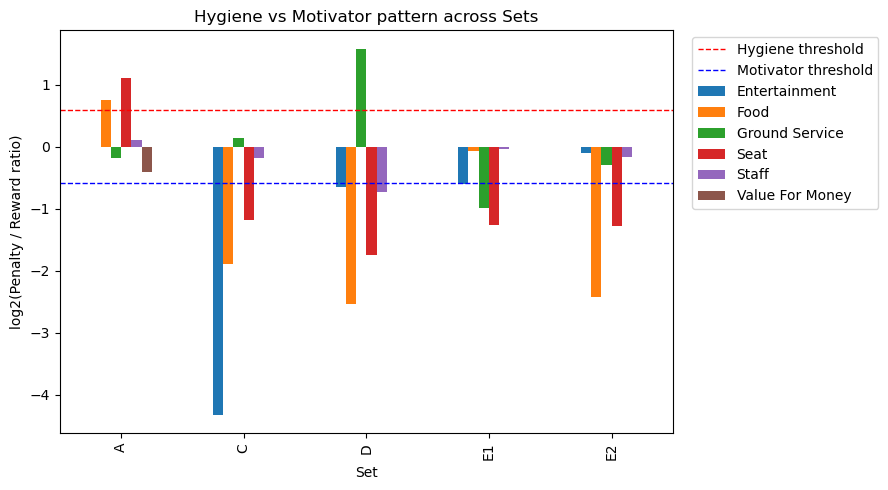

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
ratio_pivot_log = np.log2(ratio_pivot.clip(upper=10)) 
ratio_pivot_log.T.plot(kind="bar", ax=ax)
ax.axhline(np.log2(1.5), color="red", linestyle="--", linewidth=1, label="Hygiene threshold")
ax.axhline(np.log2(0.67), color="blue", linestyle="--", linewidth=1, label="Motivator threshold")
ax.set_ylabel("log2(Penalty / Reward ratio)")
ax.set_title("Hygiene vs Motivator pattern across Sets")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [33]:
import matplotlib.pyplot as plt

def plot_dependence(set_name, feature_name, ax=None, sample_size=3000):
    """
    Scatter of feature value (x) vs SHAP value (y), to visually inspect asymmetry.
    A hygiene pattern shows a steep drop on the low end and a flat/plateaued high end;
    a motivator pattern shows the reverse.
    """
    values, X_transformed = shap_results[set_name]
    names = feature_names_by_set[set_name]
    idx = list(names).index(feature_name)

    feat_vals = X_transformed[:, idx]
    shap_vals = values[:, idx]

    valid = ~np.isnan(feat_vals)
    feat_vals, shap_vals = feat_vals[valid], shap_vals[valid]

    # Subsample for readability if there are many points
    if len(feat_vals) > sample_size:
        rng = np.random.default_rng(42)
        sel = rng.choice(len(feat_vals), sample_size, replace=False)
        feat_vals, shap_vals = feat_vals[sel], shap_vals[sel]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    ax.scatter(feat_vals, shap_vals, alpha=0.15, s=8, color="steelblue")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)

    # Overlay a smoothed trend line (rolling mean over sorted feature values)
    order = np.argsort(feat_vals)
    fv_sorted, sv_sorted = feat_vals[order], shap_vals[order]
    window = max(len(fv_sorted) // 20, 10)
    trend = pd.Series(sv_sorted).rolling(window, center=True, min_periods=1).mean()
    ax.plot(fv_sorted, trend, color="red", linewidth=2)

    ax.set_xlabel(feature_name.split("__")[-1])
    ax.set_ylabel("SHAP value")
    ax.set_title(f"Set {set_name}")
    return ax

In [34]:
def plot_aspect_across_sets(aspect, aspect_map=ASPECT_MAP, save=True):
    """
    Plots the SHAP dependence scatter for a given aspect, across every Set that
    has a mapped feature for it, side by side for direct visual comparison.
    """
    set_map = aspect_map[aspect]
    n_sets = len(set_map)

    fig, axes = plt.subplots(1, n_sets, figsize=(5 * n_sets, 4))
    if n_sets == 1:
        axes = [axes]

    for ax, (set_name, feat_name) in zip(axes, set_map.items()):
        plot_dependence(set_name, feat_name, ax=ax)

    fig.suptitle(f"SHAP Dependence: {aspect} across Sets", fontsize=14)
    plt.tight_layout()

    if save:
        safe_name = aspect.replace(" ", "_").lower()
        plt.savefig(f"{FIGURES_DIR}shap_dependence_{safe_name}.png", dpi=150, bbox_inches="tight")
        print(f"Saved: {FIGURES_DIR}shap_dependence_{safe_name}.png")

    plt.show()

Saved: ../3_results/02_figures/shap_dependence_seat.png


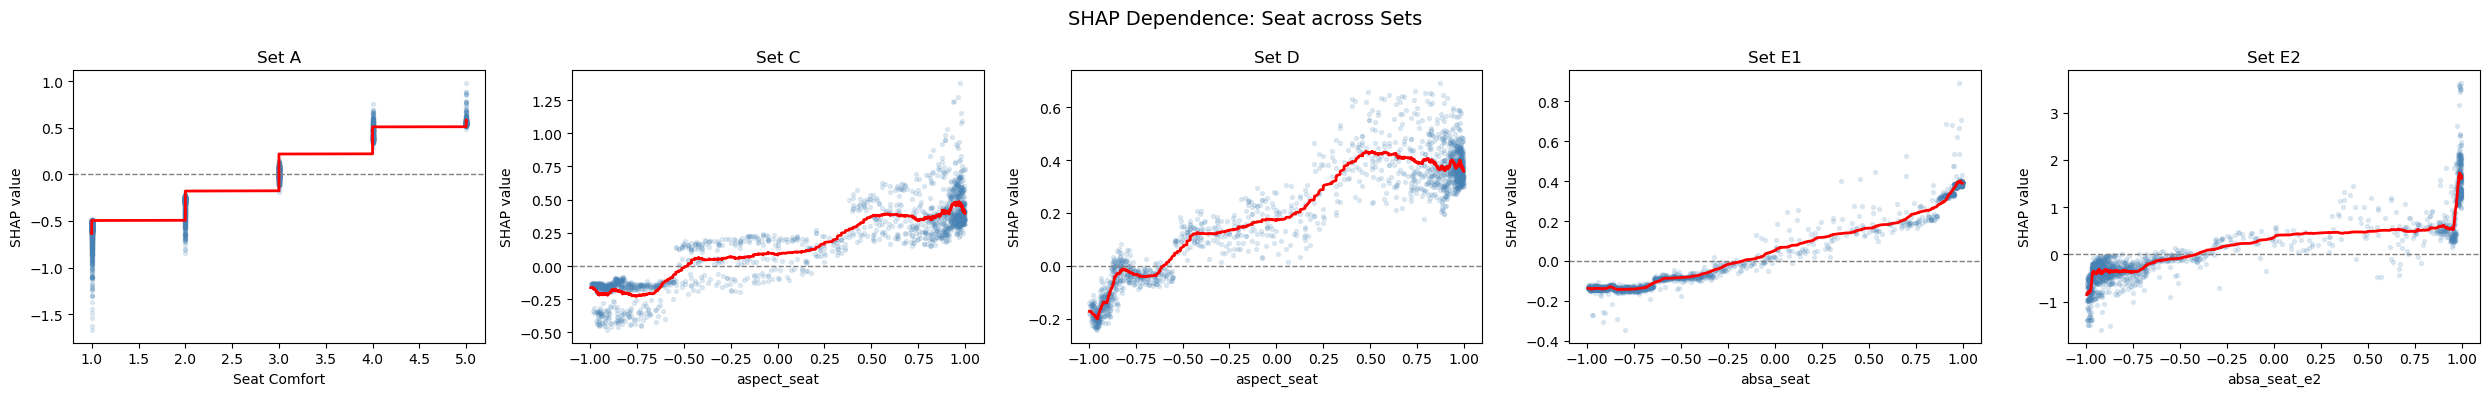

Saved: ../3_results/02_figures/shap_dependence_staff.png


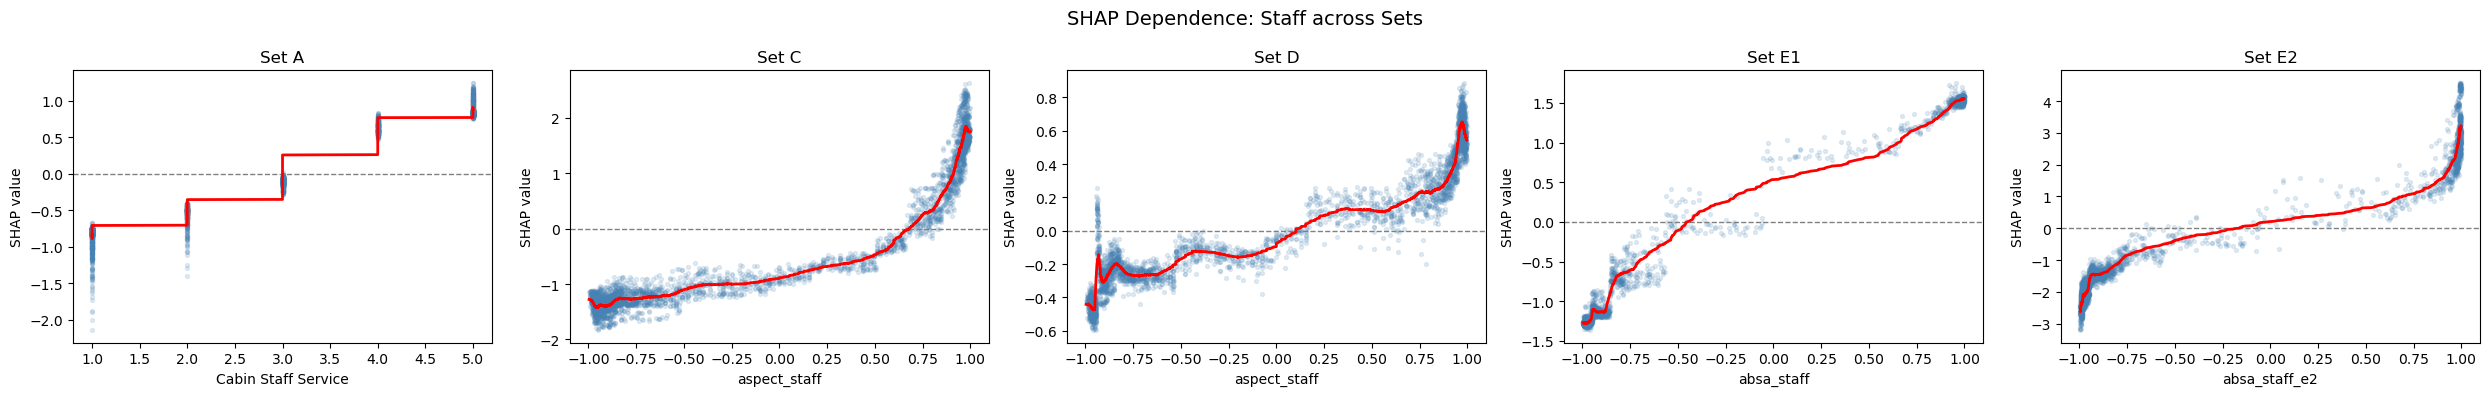

Saved: ../3_results/02_figures/shap_dependence_food.png


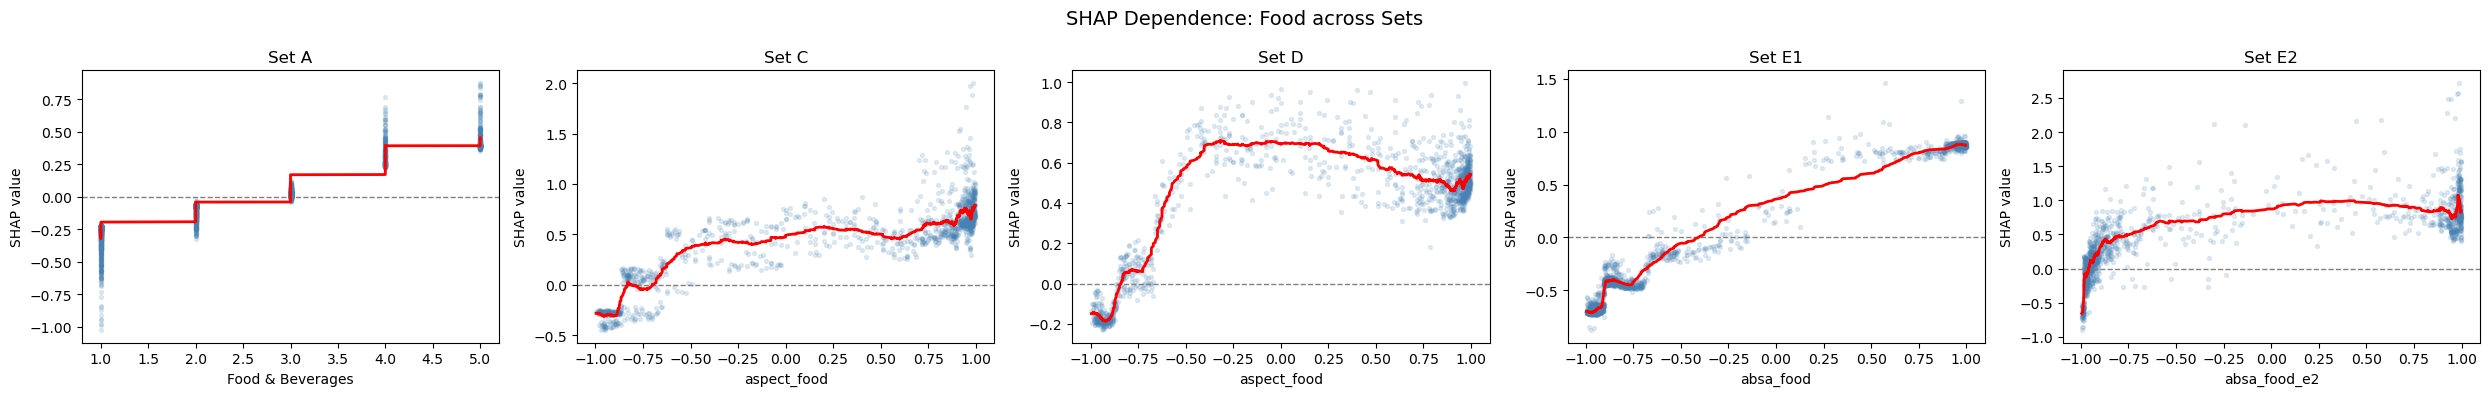

Saved: ../3_results/02_figures/shap_dependence_ground_service.png


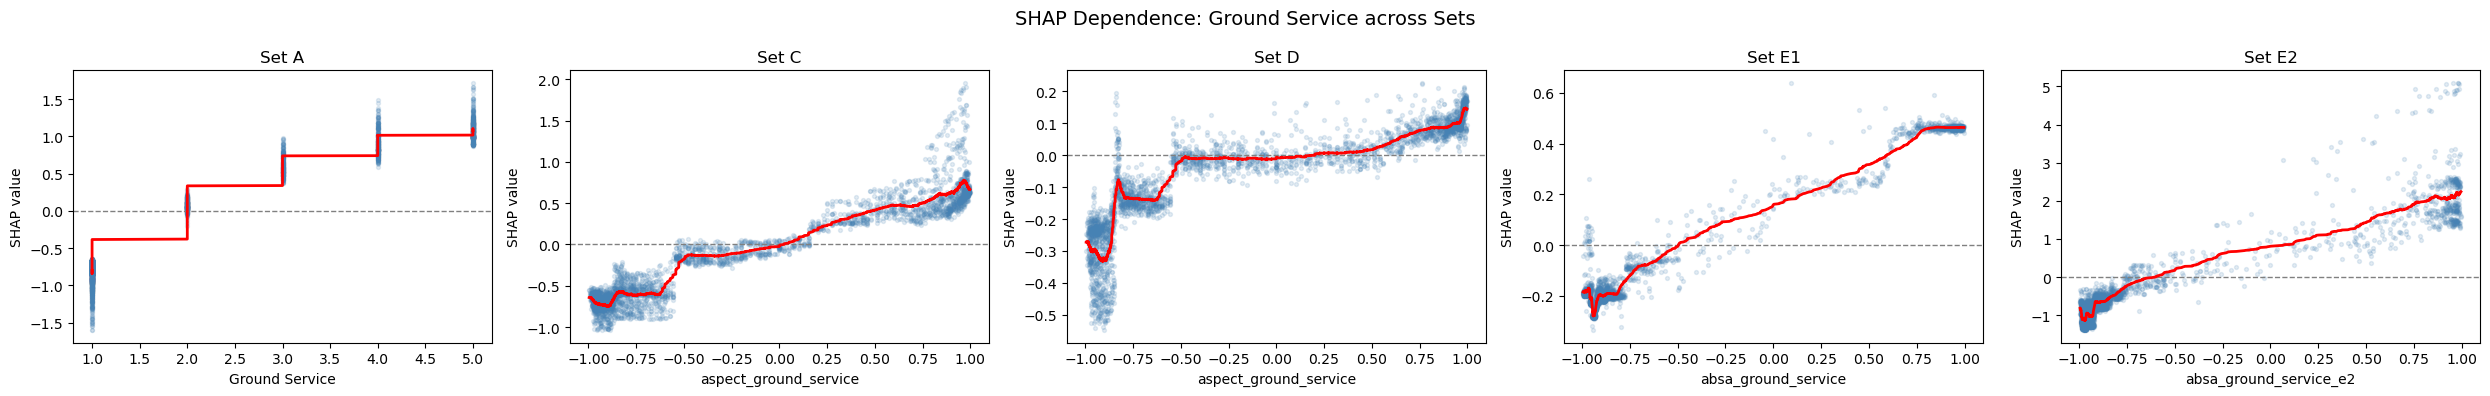

Saved: ../3_results/02_figures/shap_dependence_entertainment.png


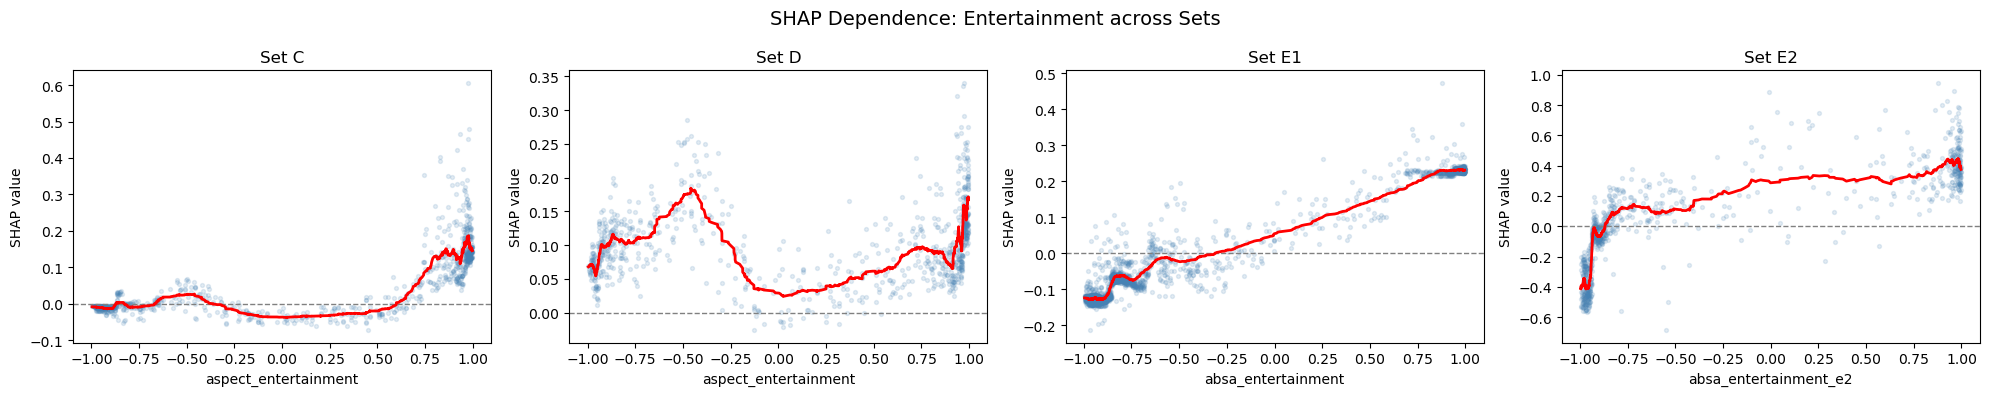

Saved: ../3_results/02_figures/shap_dependence_value_for_money.png


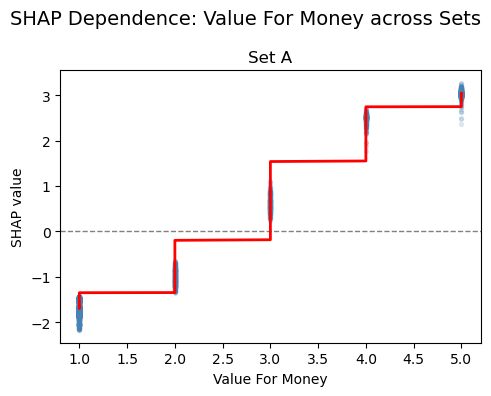

In [35]:
for aspect in ASPECT_MAP:
    plot_aspect_across_sets(aspect)

## **9. Save Results**

In [36]:
combined_importance = pd.concat(importance_tables.values(), ignore_index=True)
combined_importance = combined_importance[["Set", "Rank", "Feature", "Mean_Abs_SHAP"]]
combined_importance.to_csv(f"{METRICS_DIR}shap_importance_all_sets.csv", index=False)
print(f"Saved: {METRICS_DIR}shap_importance_all_sets.csv")

top15_per_set = combined_importance[combined_importance["Rank"] <= 15]
top15_per_set.to_csv(f"{METRICS_DIR}shap_top15_per_set.csv", index=False)
print(f"Saved: {METRICS_DIR}shap_top15_per_set.csv")

cross_set_df.to_csv(f"{METRICS_DIR}shap_cross_set_aspect_comparison.csv", index=False)
print(f"Saved: {METRICS_DIR}shap_cross_set_aspect_comparison.csv")

aspect_avg_rank.to_csv(f"{METRICS_DIR}shap_aspect_avg_rank_summary.csv", header=["Avg_Normalized_Rank"])
print(f"Saved: {METRICS_DIR}shap_aspect_avg_rank_summary.csv")

Saved: ../3_results/01_metrics/shap_importance_all_sets.csv
Saved: ../3_results/01_metrics/shap_top15_per_set.csv
Saved: ../3_results/01_metrics/shap_cross_set_aspect_comparison.csv
Saved: ../3_results/01_metrics/shap_aspect_avg_rank_summary.csv
